# 08 — Excited-state UV-Vis analysis

Compare parsed ORCA TDA singlet/triplet excitation states, simulated UV-Vis spectra, selected states for follow-up NTO/SOC analysis, and singlet-triplet energy-level diagrams for parent and terminal-functionalized PDI.


## A. Load and validate parsed TDA data


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Make figures independent of PyCharm/Jupyter dark-theme defaults.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "font.family": "DejaVu Sans",
    }
)

ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "excited_state" / "tda_uv_vis"
FIGURES = ROOT / "figures" / "excited_state_uv_vis"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

SYSTEM_ORDER = ["pdi", "pdi_terminal_functionalized"]
SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Functionalized PDI",
}
SYSTEM_COLORS = {
    "pdi": "#0018F9",
    "pdi_terminal_functionalized": "#F28500",
}
MULTIPLICITY_LABELS = {
    "singlet": "Singlet",
    "triplet": "Triplet",
}
MULTIPLICITY_MARKERS = {
    "singlet": "o",
    "triplet": "s",
}

SIGMA_EV = 0.15
STRONG_OSCILLATOR_THRESHOLD = 0.01
LOW_ENERGY_WINDOW_EV = 1.0
SINGLET_TRIPLET_PROXIMITY_EV = 0.20
MAX_SELECTED_TRIPLETS_PER_SINGLET = 2
ENERGY_MATCHING_TOLERANCE_EV = 0.15
OSCILLATOR_INCREASE_THRESHOLD = 0.05
DISPLAY_WAVELENGTH_RANGE_NM = (250, 800)

states = pd.read_csv(RESULTS / "excitation_states.csv")
transitions = pd.read_csv(RESULTS / "excitation_transitions.csv")
parse_summary = pd.read_csv(RESULTS / "tda_parse_summary.csv")

display(parse_summary)


,system,system_label,multiplicity,multiplicity_label,source_output_path,normal_termination,requested_or_detected_number_of_roots,parsed_number_of_states,minimum_excitation_energy_ev,maximum_excitation_energy_ev,number_of_states_with_oscillator_strengths,parser_warnings
0,pdi,Parent PDI,singlet,Singlet,calculations/pdi/excited_state_calculations/td...,True,30,30,2.763479,6.632666,30,NaN
1,pdi,Parent PDI,triplet,Triplet,calculations/pdi/excited_state_calculations/td...,True,15,15,1.617000,4.702000,0,NaN
2,pdi_terminal_functionalized,Terminal-functionalized PDI,singlet,Singlet,calculations/pdi_terminal_functionalized/excit...,True,30,30,2.748080,6.567085,30,NaN
3,pdi_terminal_functionalized,Terminal-functionalized PDI,triplet,Triplet,calculations/pdi_terminal_functionalized/excit...,True,15,15,1.605000,4.543000,0,NaN


In [2]:
def style_white_axes(fig, ax):
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.tick_params(
        axis="both",
        colors="black",
        labelsize=14,
        width=1.8,
        direction="in",
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.8)


def practical_chemistry_axis(
    ax,
    xlabel=None,
    ylabel=None,
    title=None,
    legend=False,
    legend_loc="best",
):
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=22, fontweight="bold")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=22, fontweight="bold")
    if title:
        ax.set_title(title, fontsize=18, fontweight="bold", pad=12)
    #ax.spines[["top", "right"]].set_visible(False)
    if legend:
        leg = ax.legend(loc=legend_loc, frameon=True, fontsize=10)
        leg.get_frame().set_edgecolor("black")
        leg.get_frame().set_linewidth(1.0)
        leg.get_frame().set_facecolor("white")
        for text in leg.get_texts():
            text.set_fontweight("bold")
    style_white_axes(ax.figure, ax)


def save_figure(fig, stem):
    fig.savefig(FIGURES / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIGURES / f"{stem}.png", dpi=300, bbox_inches="tight")


def finite_fosc(series):
    return pd.to_numeric(series, errors="coerce").fillna(0.0)


def state_sort_key(frame):
    return frame.assign(
        multiplicity_order=frame["multiplicity"].map({"singlet": 0, "triplet": 1})
    ).sort_values(["system", "multiplicity_order", "state_index"])


In [3]:
required_state_columns = {
    "system",
    "multiplicity",
    "state_index",
    "state_label",
    "excitation_energy_ev",
    "wavelength_nm",
    "oscillator_strength",
    "dominant_transitions",
}
required_transition_columns = {
    "system",
    "multiplicity",
    "state_index",
    "state_label",
    "transition_weight",
}
missing_state_columns = required_state_columns - set(states.columns)
missing_transition_columns = required_transition_columns - set(transitions.columns)

if missing_state_columns:
    raise ValueError(f"Missing columns in excitation_states.csv: {sorted(missing_state_columns)}")
if missing_transition_columns:
    raise ValueError(f"Missing columns in excitation_transitions.csv: {sorted(missing_transition_columns)}")

systems_present = set(states["system"])
if set(SYSTEM_ORDER) - systems_present:
    raise ValueError(f"Missing systems: {sorted(set(SYSTEM_ORDER) - systems_present)}")

for system in SYSTEM_ORDER:
    multiplicities = set(states.loc[states["system"] == system, "multiplicity"])
    if {"singlet", "triplet"} - multiplicities:
        raise ValueError(f"Missing singlet/triplet states for {system}")

duplicates = states.duplicated(["system", "state_label"], keep=False)
if duplicates.any():
    display(states.loc[duplicates, ["system", "state_label", "multiplicity", "state_index"]])
    raise ValueError("State labels must be unique within each system.")

if (states["excitation_energy_ev"] <= 0).any():
    raise ValueError("Excitation energies must be positive.")

present_fosc = pd.to_numeric(states["oscillator_strength"], errors="coerce").dropna()
if (present_fosc < 0).any():
    raise ValueError("Oscillator strengths must be non-negative where present.")

state_keys = set(states[["system", "multiplicity", "state_index"]].itertuples(index=False, name=None))
transition_keys = set(transitions[["system", "multiplicity", "state_index"]].itertuples(index=False, name=None))
missing_transition_targets = transition_keys - state_keys
if missing_transition_targets:
    raise ValueError(f"Transition rows map to missing states: {sorted(missing_transition_targets)[:5]}")

wavelength_check = 1239.841984 / states["excitation_energy_ev"]
if not np.allclose(states["wavelength_nm"], wavelength_check, atol=1e-8):
    raise ValueError("Wavelengths are inconsistent with excitation energies.")

concise_summary = parse_summary[[
    "system_label",
    "multiplicity_label",
    "parsed_number_of_states",
    "minimum_excitation_energy_ev",
    "maximum_excitation_energy_ev",
    "number_of_states_with_oscillator_strengths",
]]
display(concise_summary)


,system_label,multiplicity_label,parsed_number_of_states,minimum_excitation_energy_ev,maximum_excitation_energy_ev,number_of_states_with_oscillator_strengths
0,Parent PDI,Singlet,30,2.763479,6.632666,30
1,Parent PDI,Triplet,15,1.617000,4.702000,0
2,Terminal-functionalized PDI,Singlet,30,2.748080,6.567085,30
3,Terminal-functionalized PDI,Triplet,15,1.605000,4.543000,0


## B. Excitation-state tables


In [4]:
summary_columns = [
    "system",
    "system_label",
    "state_label",
    "multiplicity",
    "multiplicity_label",
    "state_index",
    "excitation_energy_ev",
    "wavelength_nm",
    "oscillator_strength",
    "dominant_transitions",
]

excitation_state_summary = state_sort_key(states[summary_columns].copy())
excitation_state_summary["excitation_energy_ev"] = excitation_state_summary["excitation_energy_ev"].round(3)
excitation_state_summary["wavelength_nm"] = excitation_state_summary["wavelength_nm"].round(1)
excitation_state_summary["oscillator_strength"] = (
    pd.to_numeric(excitation_state_summary["oscillator_strength"], errors="coerce")
    .round(4)
)
excitation_state_summary = excitation_state_summary.drop(columns=["multiplicity_order", "state_index"])
excitation_state_summary.to_csv(
    RESULTS / "excitation_state_summary.csv",
    index=False,
)

for system in SYSTEM_ORDER:
    print(SYSTEM_LABELS[system])
    for multiplicity in ["singlet", "triplet"]:
        print(f"  {MULTIPLICITY_LABELS[multiplicity]} states")
        display(
            excitation_state_summary.loc[
                (excitation_state_summary["system"] == system)
                & (excitation_state_summary["multiplicity"] == multiplicity),
                [
                    "state_label",
                    "multiplicity_label",
                    "excitation_energy_ev",
                    "wavelength_nm",
                    "oscillator_strength",
                    "dominant_transitions",
                ],
            ]
        )


Parent PDI
  Singlet states


,state_label,multiplicity_label,excitation_energy_ev,wavelength_nm,oscillator_strength,dominant_transitions
0,S1,Singlet,2.763,448.7,1.3105,HOMO → LUMO (95.3%)
1,S2,Singlet,3.861,321.2,0.0000,HOMO-1 → LUMO (71.1%); HOMO-4 → LUMO (9.5%); H...
2,S3,Singlet,4.044,306.6,0.2045,HOMO-2 → LUMO (74.7%); HOMO → LUMO+4 (10.5%); ...
3,S4,Singlet,4.105,302.0,0.0000,HOMO-4 → LUMO (60.5%); HOMO → LUMO+2 (21.0%); ...
4,S5,Singlet,4.396,282.0,0.0000,HOMO → LUMO+1 (63.1%); HOMO-3 → LUMO (28.4%)
5,S6,Singlet,4.591,270.1,0.0000,HOMO → LUMO+2 (68.7%); HOMO-4 → LUMO (24.4%)
6,S7,Singlet,4.634,267.6,0.0000,HOMO-5 → LUMO (58.8%); HOMO-6 → LUMO+1 (23.1%)...
7,S8,Singlet,4.636,267.5,0.0006,HOMO-6 → LUMO (58.6%); HOMO-5 → LUMO+1 (23.2%)...
8,S9,Singlet,4.802,258.2,0.0000,HOMO-3 → LUMO (64.0%); HOMO → LUMO+1 (28.3%)
9,S10,Singlet,4.941,250.9,0.0000,HOMO → LUMO+3 (70.2%); HOMO-1 → LUMO (12.9%)


  Triplet states


,state_label,multiplicity_label,excitation_energy_ev,wavelength_nm,oscillator_strength,dominant_transitions
30,T1,Triplet,1.617,766.8,NaN,HOMO → LUMO (89.6%)
31,T2,Triplet,2.949,420.4,NaN,HOMO-3 → LUMO (49.2%); HOMO → LUMO+1 (40.4%)
32,T3,Triplet,3.078,402.8,NaN,HOMO-4 → LUMO (46.3%); HOMO → LUMO+2 (37.8%)
33,T4,Triplet,3.294,376.4,NaN,HOMO-1 → LUMO (79.7%); HOMO-2 → LUMO+1 (9.4%)
34,T5,Triplet,3.388,366.0,NaN,HOMO-2 → LUMO (82.5%); HOMO-1 → LUMO+1 (11.7%)
35,T6,Triplet,4.196,295.5,NaN,HOMO-12 → LUMO (24.4%); HOMO-3 → LUMO+2 (22.3%...
36,T7,Triplet,4.245,292.1,NaN,HOMO → LUMO+3 (86.0%); HOMO-3 → LUMO+4 (6.8%)
37,T8,Triplet,4.339,285.7,NaN,HOMO-5 → LUMO (53.1%); HOMO-6 → LUMO+1 (23.9%)...
38,T9,Triplet,4.341,285.6,NaN,HOMO-6 → LUMO (53.0%); HOMO-5 → LUMO+1 (23.9%)...
39,T10,Triplet,4.413,281.0,NaN,HOMO → LUMO+2 (35.5%); HOMO-4 → LUMO (35.5%); ...


Functionalized PDI
  Singlet states


,state_label,multiplicity_label,excitation_energy_ev,wavelength_nm,oscillator_strength,dominant_transitions
45,S1,Singlet,2.748,451.2,1.3875,HOMO → LUMO (95.2%)
46,S2,Singlet,3.865,320.8,0.0000,HOMO-1 → LUMO (67.5%); HOMO-3 → LUMO (11.8%); ...
47,S3,Singlet,4.046,306.5,0.1699,HOMO-2 → LUMO (74.2%); HOMO → LUMO+4 (10.9%); ...
48,S4,Singlet,4.063,305.1,0.0000,HOMO-3 → LUMO (54.4%); HOMO → LUMO+2 (21.7%); ...
49,S5,Singlet,4.370,283.7,0.0000,HOMO → LUMO+1 (64.4%); HOMO-4 → LUMO (26.4%)
50,S6,Singlet,4.551,272.5,0.0000,HOMO-7 → LUMO (35.6%); HOMO-9 → LUMO (21.1%); ...
51,S7,Singlet,4.552,272.4,0.0004,HOMO-8 → LUMO (34.9%); HOMO-10 → LUMO (21.4%);...
52,S8,Singlet,4.558,272.0,0.0000,HOMO → LUMO+2 (66.1%); HOMO-3 → LUMO (21.1%)
53,S9,Singlet,4.684,264.7,0.0000,HOMO-9 → LUMO (35.9%); HOMO-7 → LUMO (20.7%); ...
54,S10,Singlet,4.703,263.6,0.0001,HOMO-10 → LUMO (34.9%); HOMO-8 → LUMO (19.8%);...


  Triplet states


,state_label,multiplicity_label,excitation_energy_ev,wavelength_nm,oscillator_strength,dominant_transitions
75,T1,Triplet,1.605,772.5,NaN,HOMO → LUMO (89.6%)
76,T2,Triplet,2.935,422.4,NaN,HOMO-4 → LUMO (47.7%); HOMO → LUMO+1 (40.9%)
77,T3,Triplet,3.089,401.4,NaN,HOMO → LUMO+2 (37.6%); HOMO-3 → LUMO (36.3%); ...
78,T4,Triplet,3.311,374.5,NaN,HOMO-1 → LUMO (79.5%); HOMO-2 → LUMO+1 (9.4%)
79,T5,Triplet,3.409,363.7,NaN,HOMO-2 → LUMO (81.6%); HOMO-1 → LUMO+1 (11.8%)
80,T6,Triplet,4.200,295.2,NaN,HOMO → LUMO+3 (64.9%); HOMO → LUMO+2 (9.0%); H...
81,T7,Triplet,4.201,295.1,NaN,HOMO → LUMO+6 (21.8%); HOMO-4 → LUMO+2 (21.4%)...
82,T8,Triplet,4.232,293.0,NaN,HOMO-3 → LUMO (29.3%); HOMO → LUMO+3 (20.2%); ...
83,T9,Triplet,4.252,291.6,NaN,HOMO-7 → LUMO (29.4%); HOMO-9 → LUMO (21.6%); ...
84,T10,Triplet,4.253,291.5,NaN,HOMO-8 → LUMO (30.1%); HOMO-10 → LUMO (20.9%);...


## C. Simulated UV-Vis spectra


In [5]:
singlets = states[states["multiplicity"] == "singlet"].copy()
singlets["oscillator_strength"] = finite_fosc(singlets["oscillator_strength"])

energy_min = max(0.5, singlets["excitation_energy_ev"].min() - 1.5)
energy_max = singlets["excitation_energy_ev"].max() + 1.5
energy_grid = np.linspace(energy_min, energy_max, 4000)


def gaussian_spectrum(
    energies_ev,
    oscillator_strengths,
    grid_ev,
    sigma_ev=SIGMA_EV,
    normalize=False,
):
    energies_ev = np.asarray(energies_ev, dtype=float)
    oscillator_strengths = np.asarray(oscillator_strengths, dtype=float)
    spectrum = np.zeros_like(grid_ev, dtype=float)

    for energy, strength in zip(energies_ev, oscillator_strengths, strict=True):
        spectrum += strength * np.exp(-0.5 * ((grid_ev - energy) / sigma_ev) ** 2)

    if normalize and spectrum.max() > 0:
        spectrum = spectrum / spectrum.max()

    return spectrum


spectra = {}
for system in SYSTEM_ORDER:
    subset = singlets[singlets["system"] == system].sort_values("excitation_energy_ev")
    spectra[system] = {
        "raw": gaussian_spectrum(
            subset["excitation_energy_ev"],
            subset["oscillator_strength"],
            energy_grid,
            sigma_ev=SIGMA_EV,
            normalize=False,
        ),
        "normalized": gaussian_spectrum(
            subset["excitation_energy_ev"],
            subset["oscillator_strength"],
            energy_grid,
            sigma_ev=SIGMA_EV,
            normalize=True,
        ),
    }

wavelength_grid = 1239.841984 / energy_grid
wavelength_order = np.argsort(wavelength_grid)
plot_wavelength = wavelength_grid[wavelength_order]

print(f"Gaussian broadening is applied in energy space with sigma = {SIGMA_EV:.2f} eV.")


Gaussian broadening is applied in energy space with sigma = 0.15 eV.


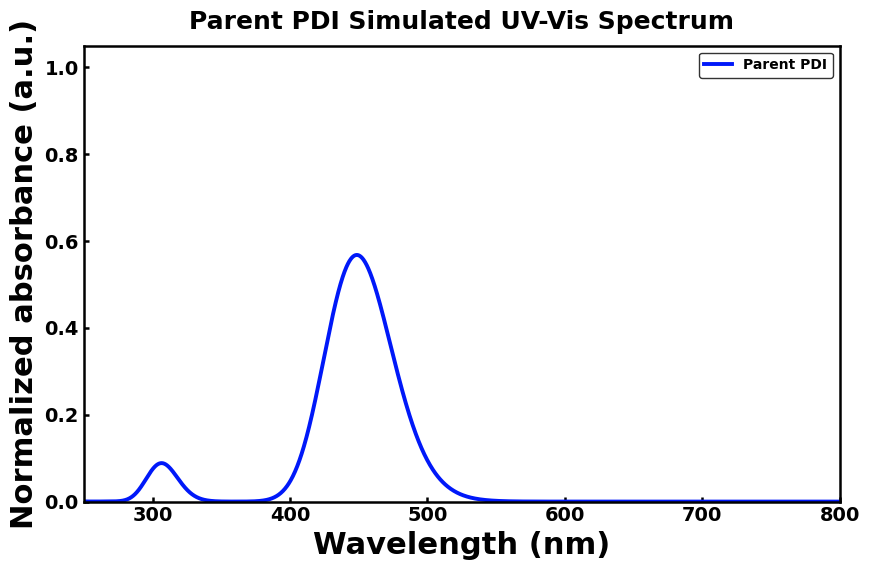

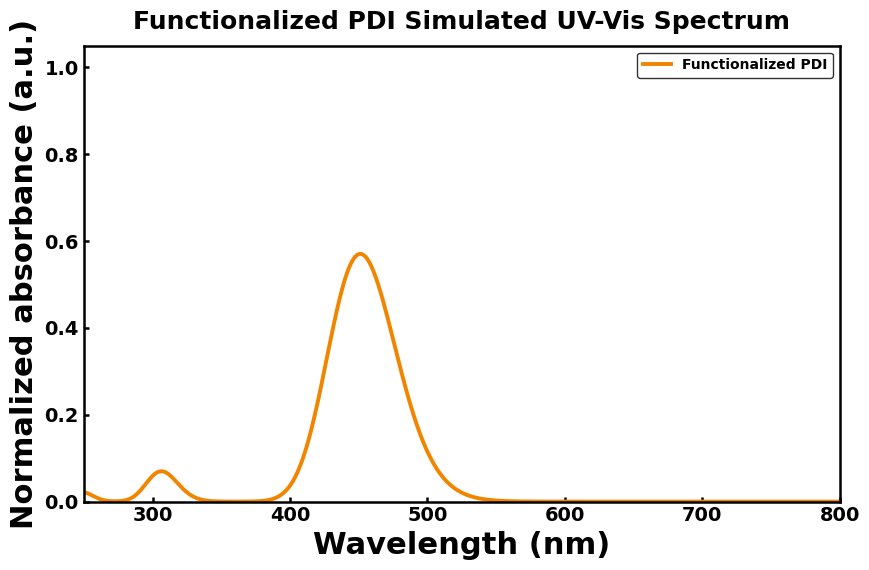

In [6]:
def plot_system_spectrum(system, normalized=True):
    mode = "normalized" if normalized else "raw"
    y_values = spectra[system][mode][wavelength_order]
    subset = singlets[singlets["system"] == system].copy()

    fig, ax = plt.subplots(figsize=(8.8, 5.8), facecolor="white")
    ax.plot(
        plot_wavelength,
        y_values,
        color=SYSTEM_COLORS[system],
        linewidth=2.8,
        label=SYSTEM_LABELS[system],
    )

    stick_scale = 0.18 * y_values.max() / max(subset["oscillator_strength"].max(), 1e-12)

    ax.set_xlim(*DISPLAY_WAVELENGTH_RANGE_NM)
    ax.set_ylim(bottom=0)
    ylabel = "Normalized absorbance (a.u.)" if normalized else "Raw broadened oscillator strength"
    practical_chemistry_axis(
        ax,
        xlabel="Wavelength (nm)",
        ylabel=ylabel,
        title=f"{SYSTEM_LABELS[system]} Simulated UV-Vis Spectrum",
        legend=True,
        legend_loc="upper right",
    )
    plt.tight_layout()
    #save_figure(fig, f"{system}_simulated_uv_vis")
    plt.show()


for system in SYSTEM_ORDER:
    plot_system_spectrum(system, normalized=True)


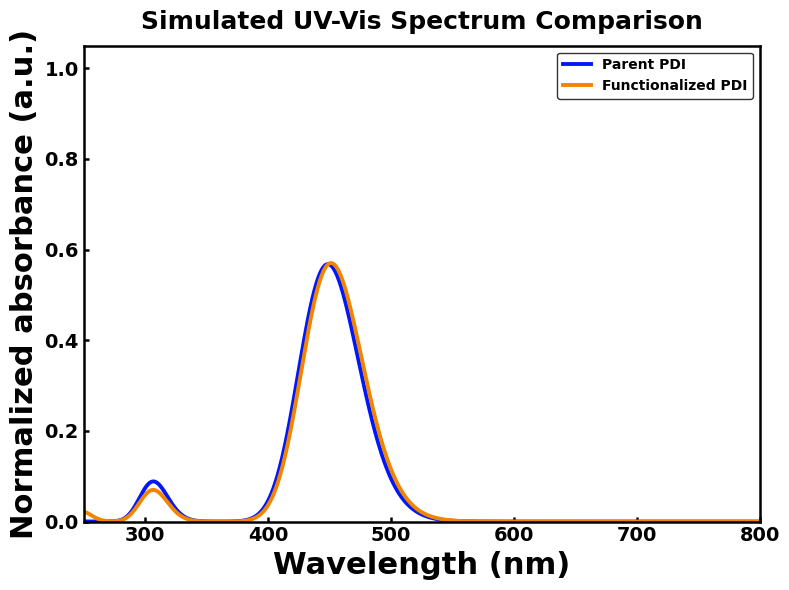

In [7]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
for system in SYSTEM_ORDER:
    ax.plot(
        plot_wavelength,
        spectra[system]["normalized"][wavelength_order],
        color=SYSTEM_COLORS[system],
        linewidth=2.8,
        label=SYSTEM_LABELS[system],
    )
ax.set_xlim(*DISPLAY_WAVELENGTH_RANGE_NM)
ax.set_ylim(bottom=0)
practical_chemistry_axis(
    ax,
    xlabel="Wavelength (nm)",
    ylabel="Normalized absorbance (a.u.)",
    title="Simulated UV-Vis Spectrum Comparison",
    legend=True,
    legend_loc="upper right",
)
plt.tight_layout()
save_figure(fig, "simulated_uv_vis_comparison_normalized")
plt.show()

plt.show()


In [8]:
def first_strong_singlet(group):
    strong = group[group["oscillator_strength"] >= STRONG_OSCILLATOR_THRESHOLD]
    if strong.empty:
        return group.sort_values("oscillator_strength", ascending=False).iloc[0]
    return strong.sort_values("excitation_energy_ev").iloc[0]


uv_vis_key_rows = []
for system in SYSTEM_ORDER:
    group = singlets[singlets["system"] == system].sort_values("excitation_energy_ev")
    lowest = group.iloc[0]
    first_allowed = first_strong_singlet(group)
    brightest = group.sort_values("oscillator_strength", ascending=False).iloc[0]
    uv_vis_key_rows.append(
        {
            "system": system,
            "system_label": SYSTEM_LABELS[system],
            "lowest_singlet_state": lowest["state_label"],
            "lowest_singlet_energy_ev": lowest["excitation_energy_ev"],
            "lowest_singlet_wavelength_nm": lowest["wavelength_nm"],
            "first_non_negligible_state": first_allowed["state_label"],
            "first_non_negligible_energy_ev": first_allowed["excitation_energy_ev"],
            "first_non_negligible_wavelength_nm": first_allowed["wavelength_nm"],
            "first_non_negligible_oscillator_strength": first_allowed["oscillator_strength"],
            "brightest_state": brightest["state_label"],
            "brightest_state_energy_ev": brightest["excitation_energy_ev"],
            "brightest_state_wavelength_nm": brightest["wavelength_nm"],
            "brightest_state_oscillator_strength": brightest["oscillator_strength"],
        }
    )

uv_vis_key_states = pd.DataFrame(uv_vis_key_rows)
uv_vis_key_states.to_csv(RESULTS / "uv_vis_key_states.csv", index=False)
display(uv_vis_key_states)


,system,system_label,lowest_singlet_state,lowest_singlet_energy_ev,lowest_singlet_wavelength_nm,first_non_negligible_state,first_non_negligible_energy_ev,first_non_negligible_wavelength_nm,first_non_negligible_oscillator_strength,brightest_state,brightest_state_energy_ev,brightest_state_wavelength_nm,brightest_state_oscillator_strength
0,pdi,Parent PDI,S1,2.763479,448.652580,S1,2.763479,448.652580,1.310531,S28,6.492992,190.950795,1.626342
1,pdi_terminal_functionalized,Functionalized PDI,S1,2.748080,451.166627,S1,2.748080,451.166627,1.387530,S28,6.478461,191.379092,1.747763


## D. Automated selection of chemically important states


In [9]:
def add_selection(
    selections,
    state,
    reason,
    related_state="",
    delta_e=np.nan,
    nto=True,
    soc=False,
):
    key = (state["system"], state["multiplicity"], int(state["state_index"]))
    if key not in selections:
        selections[key] = {
            "system": state["system"],
            "system_label": SYSTEM_LABELS[state["system"]],
            "state_label": state["state_label"],
            "state_index": int(state["state_index"]),
            "multiplicity": state["multiplicity"],
            "multiplicity_label": MULTIPLICITY_LABELS[state["multiplicity"]],
            "excitation_energy_ev": state["excitation_energy_ev"],
            "wavelength_nm": state["wavelength_nm"],
            "oscillator_strength": state["oscillator_strength"],
            "dominant_transitions": state["dominant_transitions"],
            "selection_reason": [],
            "related_singlet_or_triplet_state": [],
            "singlet_triplet_energy_separation_ev": [],
            "recommended_for_nto_analysis": bool(nto),
            "recommended_for_singlet_triplet_soc_screening": bool(soc),
        }
    selections[key]["selection_reason"].append(reason)
    if related_state:
        selections[key]["related_singlet_or_triplet_state"].append(related_state)
    if np.isfinite(delta_e):
        selections[key]["singlet_triplet_energy_separation_ev"].append(delta_e)
    selections[key]["recommended_for_nto_analysis"] |= bool(nto)
    selections[key]["recommended_for_singlet_triplet_soc_screening"] |= bool(soc)


def functionalization_candidate():
    parent = singlets[singlets["system"] == "pdi"].copy()
    functionalized = singlets[singlets["system"] == "pdi_terminal_functionalized"].copy()
    parent_s1 = parent["excitation_energy_ev"].min()
    functionalized_s1 = functionalized["excitation_energy_ev"].min()
    parent = parent.assign(relative_energy_ev=parent["excitation_energy_ev"] - parent_s1)
    functionalized = functionalized.assign(
        relative_energy_ev=functionalized["excitation_energy_ev"] - functionalized_s1
    )
    candidates = []

    for row in functionalized.itertuples(index=False):
        if row.relative_energy_ev > LOW_ENERGY_WINDOW_EV or row.state_label == "S1":
            continue
        diffs = (parent["relative_energy_ev"] - row.relative_energy_ev).abs()
        nearest = parent.loc[diffs.idxmin()]
        energy_gap = float(abs(nearest["relative_energy_ev"] - row.relative_energy_ev))
        oscillator_increase = float(row.oscillator_strength - nearest["oscillator_strength"])
        reasons = []
        if energy_gap > ENERGY_MATCHING_TOLERANCE_EV:
            reasons.append("no close parent counterpart")
        if oscillator_increase >= OSCILLATOR_INCREASE_THRESHOLD:
            reasons.append("increased oscillator strength versus nearest parent state")
        if reasons:
            candidates.append((row, reasons, energy_gap, oscillator_increase))

    if not candidates:
        return None, "none identified"
    candidates.sort(key=lambda item: (-item[3], item[2], item[0].excitation_energy_ev))
    row, reasons, _, _ = candidates[0]
    return pd.Series(row._asdict()), "; ".join(reasons)


selected_records = []
functionalization_status = {}

for system in SYSTEM_ORDER:
    selections = {}
    singlet_group = singlets[singlets["system"] == system].sort_values("excitation_energy_ev")
    triplet_group = states[
        (states["system"] == system)
        & (states["multiplicity"] == "triplet")
    ].sort_values("excitation_energy_ev")

    s1 = singlet_group.iloc[0]
    t1 = triplet_group.iloc[0]
    first_allowed = first_strong_singlet(singlet_group)
    if first_allowed["oscillator_strength"] < STRONG_OSCILLATOR_THRESHOLD:
        first_allowed_reason = "fallback brightest singlet; no state reaches threshold"
    else:
        first_allowed_reason = "first strongly allowed singlet"

    low_window = singlet_group[
        singlet_group["excitation_energy_ev"]
        <= s1["excitation_energy_ev"] + LOW_ENERGY_WINDOW_EV
    ]
    brightest_low = low_window.sort_values("oscillator_strength", ascending=False).iloc[0]

    add_selection(selections, s1, "S1 lowest-energy singlet", nto=True, soc=False)
    add_selection(selections, first_allowed, first_allowed_reason, nto=True, soc=False)
    add_selection(selections, brightest_low, "brightest low-energy singlet", nto=True, soc=False)
    add_selection(selections, t1, "T1 lowest-energy triplet", nto=True, soc=False)

    if system == "pdi_terminal_functionalized":
        candidate, reason = functionalization_candidate()
        functionalization_status[system] = reason
        if candidate is not None:
            add_selection(
                selections,
                candidate,
                f"functionalization-induced low-energy candidate: {reason}",
                nto=True,
                soc=False,
            )
    else:
        functionalization_status[system] = "not applicable to parent reference"

    important_singlets = [
        record for record in selections.values() if record["multiplicity"] == "singlet"
    ]
    for singlet_record in important_singlets:
        gaps = (triplet_group["excitation_energy_ev"] - singlet_record["excitation_energy_ev"]).abs()
        close_triplets = triplet_group.loc[gaps <= SINGLET_TRIPLET_PROXIMITY_EV].copy()
        close_triplets = close_triplets.assign(delta_e_ev=gaps.loc[close_triplets.index])
        close_triplets = close_triplets.sort_values("delta_e_ev").head(
            MAX_SELECTED_TRIPLETS_PER_SINGLET
        )
        for triplet in close_triplets.itertuples(index=False):
            triplet_series = pd.Series(triplet._asdict())
            add_selection(
                selections,
                triplet_series,
                f"triplet within {SINGLET_TRIPLET_PROXIMITY_EV:.2f} eV of {singlet_record['state_label']}",
                related_state=singlet_record["state_label"],
                delta_e=float(triplet.delta_e_ev),
                nto=False,
                soc=True,
            )

    for record in selections.values():
        record["selection_reason"] = "; ".join(dict.fromkeys(record["selection_reason"]))
        record["related_singlet_or_triplet_state"] = "; ".join(
            dict.fromkeys(record["related_singlet_or_triplet_state"])
        )
        gaps = record["singlet_triplet_energy_separation_ev"]
        record["singlet_triplet_energy_separation_ev"] = min(gaps) if gaps else np.nan
        selected_records.append(record)

selected_excited_states = pd.DataFrame(selected_records)
selected_excited_states = state_sort_key(selected_excited_states).drop(columns="multiplicity_order")
selected_excited_states.to_csv(RESULTS / "selected_excited_states.csv", index=False)
display(selected_excited_states)


,system,system_label,state_label,state_index,multiplicity,multiplicity_label,excitation_energy_ev,wavelength_nm,oscillator_strength,dominant_transitions,selection_reason,related_singlet_or_triplet_state,singlet_triplet_energy_separation_ev,recommended_for_nto_analysis,recommended_for_singlet_triplet_soc_screening
0,pdi,Parent PDI,S1,1,singlet,Singlet,2.763479,448.652580,1.310531,HOMO → LUMO (95.3%),S1 lowest-energy singlet; first strongly allow...,,NaN,True,False
1,pdi,Parent PDI,T1,1,triplet,Triplet,1.617000,766.754474,NaN,HOMO → LUMO (89.6%),T1 lowest-energy triplet,,NaN,True,False
2,pdi,Parent PDI,T2,2,triplet,Triplet,2.949000,420.427936,NaN,HOMO-3 → LUMO (49.2%); HOMO → LUMO+1 (40.4%),triplet within 0.20 eV of S1,S1,0.185521,False,True
3,pdi_terminal_functionalized,Functionalized PDI,S1,1,singlet,Singlet,2.748080,451.166627,1.387530,HOMO → LUMO (95.2%),S1 lowest-energy singlet; first strongly allow...,,NaN,True,False
4,pdi_terminal_functionalized,Functionalized PDI,T1,1,triplet,Triplet,1.605000,772.487217,NaN,HOMO → LUMO (89.6%),T1 lowest-energy triplet,,NaN,True,False
5,pdi_terminal_functionalized,Functionalized PDI,T2,2,triplet,Triplet,2.935000,422.433385,NaN,HOMO-4 → LUMO (47.7%); HOMO → LUMO+1 (40.9%),triplet within 0.20 eV of S1,S1,0.186920,False,True


## E. Singlet-triplet energy-level visualization


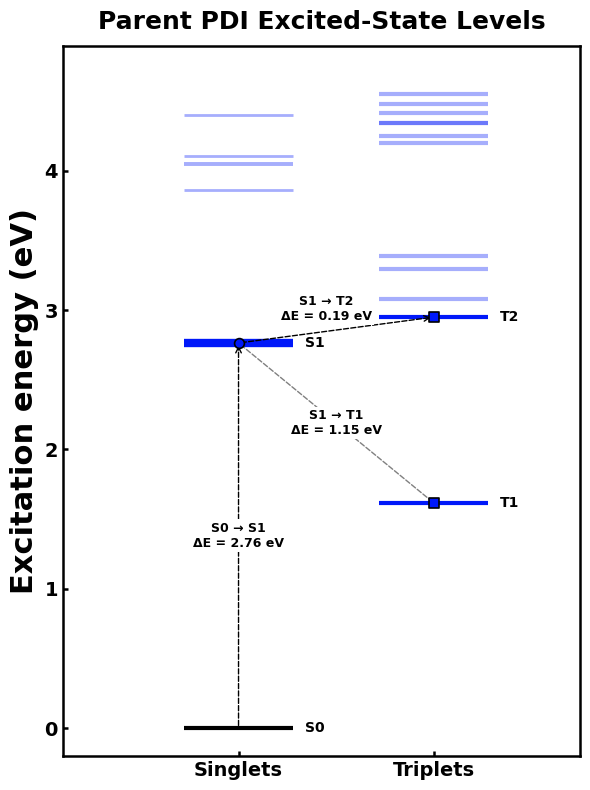

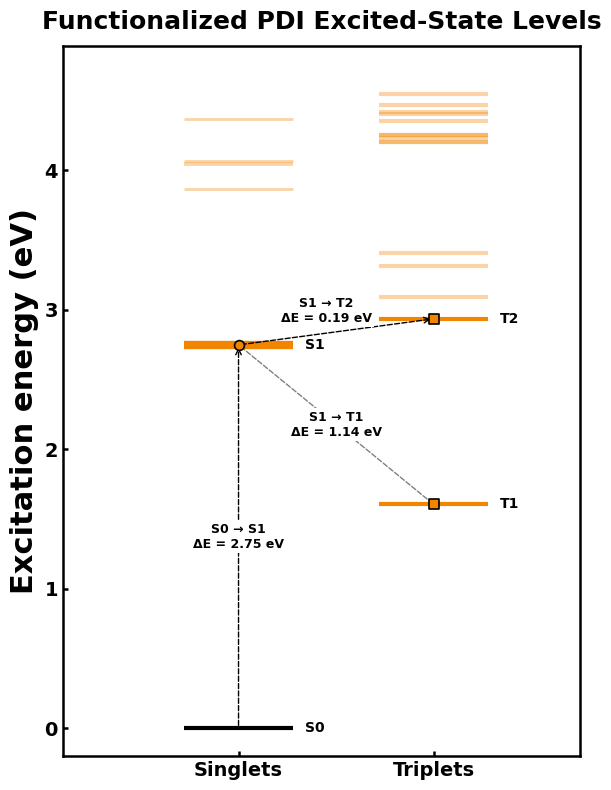

In [10]:
def plot_energy_levels(system):
    system_states = states[states["system"] == system].copy()
    selected = selected_excited_states[selected_excited_states["system"] == system]
    selected_labels = set(selected["state_label"])

    s1 = system_states[
        (system_states["multiplicity"] == "singlet")
        & (system_states["state_label"] == "S1")
    ].iloc[0]
    t1 = system_states[
        (system_states["multiplicity"] == "triplet")
        & (system_states["state_label"] == "T1")
    ].iloc[0]
    t2 = system_states[
        (system_states["multiplicity"] == "triplet")
        & (system_states["state_label"] == "T2")
    ].iloc[0]

    singlet_limit = (
        system_states.loc[
            system_states["multiplicity"] == "singlet",
            "excitation_energy_ev",
        ].min()
        + LOW_ENERGY_WINDOW_EV
        + 0.8
    )
    plot_states = system_states[
        (system_states["excitation_energy_ev"] <= singlet_limit)
        | (system_states["state_label"].isin(selected_labels))
    ].copy()
    plot_states["oscillator_strength"] = finite_fosc(plot_states["oscillator_strength"])

    fig, ax = plt.subplots(figsize=(6, 8), facecolor="white")
    x_positions = {"singlet": 0.0, "triplet": 1.0}

    ax.hlines(
        0.0,
        x_positions["singlet"] - 0.28,
        x_positions["singlet"] + 0.28,
        color="black",
        linewidth=3.0,
        alpha=1.0,
    )
    ax.text(
        x_positions["singlet"] + 0.34,
        0.0,
        "S0",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

    for row in plot_states.itertuples(index=False):
        x = x_positions[row.multiplicity]
        is_selected = row.state_label in selected_labels
        line_width = 2.0 + 4.0 * min(float(row.oscillator_strength), 1.0)
        ax.hlines(
            row.excitation_energy_ev,
            x - 0.28,
            x + 0.28,
            color=SYSTEM_COLORS[system],
            linewidth=line_width if row.multiplicity == "singlet" else 3.0,
            alpha=1.0 if is_selected else 0.35,
        )
        if is_selected:
            ax.scatter(
                x,
                row.excitation_energy_ev,
                s=50,
                marker=MULTIPLICITY_MARKERS[row.multiplicity],
                color=SYSTEM_COLORS[system],
                edgecolor="black",
                linewidth=1.2,
                zorder=4,
            )
            ax.text(
                x + 0.34,
                row.excitation_energy_ev,
                row.state_label,
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold",
                color="black",
            )

    ax.annotate(
        "",
        xy=(0, s1["excitation_energy_ev"]),
        xytext=(0, 0.0),
        arrowprops={"arrowstyle": "->", "color": "black", "lw": 1.0, "linestyle": "--"},
    )
    ax.text(
        0,
        0.5 * s1["excitation_energy_ev"],
        f"S0 → S1\nΔE = {s1['excitation_energy_ev']:.2f} eV",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5},
    )

    ax.annotate(
        "",
        xy=(1.0, t1["excitation_energy_ev"]),
        xytext=(0.0, s1["excitation_energy_ev"]),
        arrowprops={"arrowstyle": "-", "color": "gray", "lw": 1.0, "linestyle": "--"},
    )
    ax.text(
        0.50,
        0.5 * (s1["excitation_energy_ev"] + t1["excitation_energy_ev"]),
        f"S1 → T1\nΔE = {s1['excitation_energy_ev'] - t1['excitation_energy_ev']:.2f} eV",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5},
    )

    ax.annotate(
        "",
        xy=(1.0, t2["excitation_energy_ev"]),
        xytext=(0.0, s1["excitation_energy_ev"]),
        arrowprops={"arrowstyle": "->", "color": "black", "lw": 1.0, "linestyle": "--"},x
    )
    ax.text(
        0.45,
        0.5 * (s1["excitation_energy_ev"] + t2["excitation_energy_ev"] + 0.30),
        f"S1 → T2\nΔE = {abs(s1['excitation_energy_ev'] - t2['excitation_energy_ev']):.2f} eV",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5},
    )

    ax.set_xticks([0.0, 1.0])
    ax.set_xticklabels(["Singlets", "Triplets"])
    ax.set_xlim(-0.90, 1.75)
    ax.set_ylim(-0.20, plot_states["excitation_energy_ev"].max() + 0.35)
    practical_chemistry_axis(
        ax,
        ylabel="Excitation energy (eV)",
        title=f"{SYSTEM_LABELS[system]} Excited-State Levels",
    )
    plt.tight_layout()
    save_figure(fig, f"{system}_singlet_triplet_energy_levels")
    plt.show()


for system in SYSTEM_ORDER:
    plot_energy_levels(system)


## F. Interpretation summary


In [11]:
interpretation_rows = []
for system in SYSTEM_ORDER:
    singlet_group = singlets[singlets["system"] == system].sort_values("excitation_energy_ev")
    triplet_group = states[
        (states["system"] == system)
        & (states["multiplicity"] == "triplet")
    ].sort_values("excitation_energy_ev")
    s1 = singlet_group.iloc[0]
    t1 = triplet_group.iloc[0]
    low_window = singlet_group[
        singlet_group["excitation_energy_ev"]
        <= s1["excitation_energy_ev"] + LOW_ENERGY_WINDOW_EV
    ]
    brightest_low = low_window.sort_values("oscillator_strength", ascending=False).iloc[0]
    first_allowed = first_strong_singlet(singlet_group)
    gaps = (triplet_group["excitation_energy_ev"] - brightest_low["excitation_energy_ev"]).abs()
    nearest_triplet = triplet_group.loc[gaps.idxmin()]

    interpretation_rows.append(
        {
            "system": system,
            "system_label": SYSTEM_LABELS[system],
            "s1_energy_ev": s1["excitation_energy_ev"],
            "s1_wavelength_nm": s1["wavelength_nm"],
            "brightest_low_energy_singlet": brightest_low["state_label"],
            "brightest_low_energy_singlet_energy_ev": brightest_low["excitation_energy_ev"],
            "first_strongly_allowed_singlet": first_allowed["state_label"],
            "first_strongly_allowed_singlet_energy_ev": first_allowed["excitation_energy_ev"],
            "t1_energy_ev": t1["excitation_energy_ev"],
            "s1_t1_gap_ev": s1["excitation_energy_ev"] - t1["excitation_energy_ev"],
            "nearest_triplet_to_main_bright_singlet": nearest_triplet["state_label"],
            "nearest_triplet_gap_to_main_bright_singlet_ev": abs(
                nearest_triplet["excitation_energy_ev"] - brightest_low["excitation_energy_ev"]
            ),
            "functionalization_induced_low_energy_state": functionalization_status[system],
        }
    )

interpretation_summary = pd.DataFrame(interpretation_rows)
interpretation_summary.to_csv(
    RESULTS / "uv_vis_interpretation_summary.csv",
    index=False,
)
display(interpretation_summary)


,system,system_label,s1_energy_ev,s1_wavelength_nm,brightest_low_energy_singlet,brightest_low_energy_singlet_energy_ev,first_strongly_allowed_singlet,first_strongly_allowed_singlet_energy_ev,t1_energy_ev,s1_t1_gap_ev,nearest_triplet_to_main_bright_singlet,nearest_triplet_gap_to_main_bright_singlet_ev,functionalization_induced_low_energy_state
0,pdi,Parent PDI,2.763479,448.652580,S1,2.763479,S1,2.763479,1.617,1.146479,T2,0.185521,not applicable to parent reference
1,pdi_terminal_functionalized,Functionalized PDI,2.748080,451.166627,S1,2.748080,S1,2.748080,1.605,1.143080,T2,0.186920,none identified
